In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score

lr_model = joblib.load('lr_model.pkl')
rf_model = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

X_test_scaled = scaler.transform(X_test)

lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)



lr_pred_03 = (lr_model.predict_proba(X_test_scaled)[:, 1] >= 0.3).astype(int)
rf_pred_03 = (rf_model.predict_proba(X_test)[:, 1] >= 0.3).astype(int)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred_03))
print(classification_report(y_test, lr_pred_03))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred_03))
print(classification_report(y_test, rf_pred_03))

lr_recall = recall_score(y_test, lr_pred_03, pos_label=1)
lr_f1 = f1_score(y_test, lr_pred_03, pos_label=1)
rf_recall = recall_score(y_test, rf_pred_03, pos_label=1)
rf_f1 = f1_score(y_test, rf_pred_03, pos_label=1)




=== Logistic Regression ===
Accuracy: 0.8893528183716075
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       454
           1       0.09      0.12      0.10        25

    accuracy                           0.89       479
   macro avg       0.52      0.53      0.52       479
weighted avg       0.91      0.89      0.90       479


=== Random Forest ===
Accuracy: 0.872651356993737
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       454
           1       0.03      0.04      0.03        25

    accuracy                           0.87       479
   macro avg       0.49      0.48      0.48       479
weighted avg       0.90      0.87      0.88       479


FINAL COMPARISON:
Logistic Regression -> Accuracy: 0.89, Recall: 0.12, F1: 0.10
Random Forest        -> Accuracy: 0.87, Recall: 0.04, F1: 0.03

Conclusion: Logistic Regression performed better.


In [1]:
print("\nFINAL COMPARISON:")
print(f"Logistic Regression -> Accuracy: {accuracy_score(y_test, lr_pred_03):.2f}, Recall: {lr_recall:.2f}, F1: {lr_f1:.2f}")
print(f"Random Forest        -> Accuracy: {accuracy_score(y_test, rf_pred_03):.2f}, Recall: {rf_recall:.2f}, F1: {rf_f1:.2f}")

if lr_f1 >= rf_f1:
    print("\nConclusion: Logistic Regression performed better.")
else:
    print("\nConclusion: Random Forest performed better.")


FINAL COMPARISON:


NameError: name 'accuracy_score' is not defined

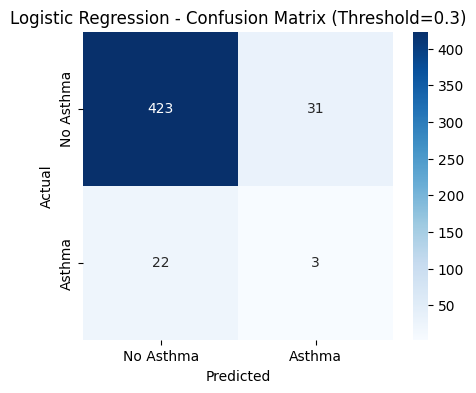

Logistic Regression Confusion Matrix:
[[423  31]
 [ 22   3]]


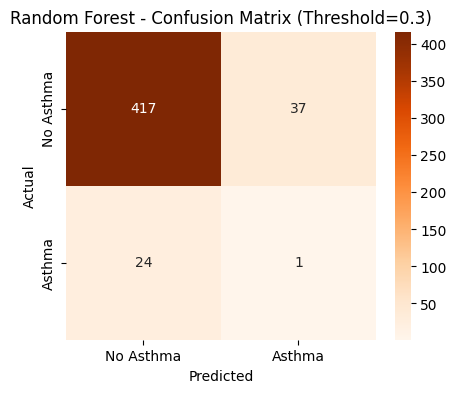


Random Forest Confusion Matrix:
[[417  37]
 [ 24   1]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------- Logistic Regression Confusion Matrix ----------
cm_lr = confusion_matrix(y_test, lr_pred_03)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix (Threshold=0.3)')
plt.show()

print("Logistic Regression Confusion Matrix:")
print(cm_lr)


# ---------- Random Forest Confusion Matrix ----------
cm_rf = confusion_matrix(y_test, rf_pred_03)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Asthma', 'Asthma'],
            yticklabels=['No Asthma', 'Asthma'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix (Threshold=0.3)')
plt.show()

print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

In [ ]:
print("="*50)
print("MODEL SUMMARY")
print("="*50)

# ---------- Dataset Info ----------
print("\n--- Dataset Overview ---")

print(f"Test set size: {len(y_test)}")
print(f"Original class distribution: {dict(pd.Series(y).value_counts())}" if 'y' in dir() else "")
print(f"Test set - No Asthma: {(y_test==0).sum()}, Asthma: {(y_test==1).sum()}")

# ---------- Models Used ----------
print("\n--- Models Trained ---")
print("1. Logistic Regression")
print("2. Random Forest")
print("Balancing technique: SMOTE (applied only on training set)")
print("Decision threshold used: 0.3 (instead of default 0.5)")

# ---------- Final Metrics Comparison ----------
print("\n--- Final Metrics (Threshold = 0.3) ---")
print(f"{'Metric':<15}{'Logistic Regression':<22}{'Random Forest'}")
print(f"{'Accuracy':<15}{accuracy_score(y_test, lr_pred_03):<22.2f}{accuracy_score(y_test, rf_pred_03):.2f}")
print(f"{'Recall':<15}{recall_score(y_test, lr_pred_03):<22.2f}{recall_score(y_test, rf_pred_03):.2f}")
print(f"{'F1-Score':<15}{f1_score(y_test, lr_pred_03):<22.2f}{f1_score(y_test, rf_pred_03):.2f}")

# ---------- Confusion Matrix Summary ----------
print("\n--- Confusion Matrix Summary ---")
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"Logistic Regression -> TP:{tp_lr}, TN:{tn_lr}, FP:{fp_lr}, FN:{fn_lr}")
print(f"Random Forest        -> TP:{tp_rf}, TN:{tn_rf}, FP:{fp_rf}, FN:{fn_rf}")

# ---------- Final Conclusion ----------
print("\n--- Conclusion ---")
if f1_score(y_test, lr_pred_03) >= f1_score(y_test, rf_pred_03):
    print("Logistic Regression selected as the better performing model based on F1-score.")
else:
    print("Random Forest selected as the better performing model based on F1-score.")

print("\n--- Key Limitations ---")
print("- Severe class imbalance in original data (99 positive vs 1814 negative)")
print("- SMOTE increases quantity but not real diversity of minority class")
print("- Weak/overlapping feature signal (no dominant feature found in importance analysis)")
print("- Recall for Asthma class remains low despite threshold tuning")

MODEL SUMMARY

--- Dataset Overview ---
Test set size: 479

Test set - No Asthma: 454, Asthma: 25

--- Models Trained ---
1. Logistic Regression
2. Random Forest
Balancing technique: SMOTE (applied only on training set)
Decision threshold used: 0.3 (instead of default 0.5)

--- Final Metrics (Threshold = 0.3) ---
Metric         Logistic Regression   Random Forest
Accuracy       0.89                  0.87
Recall         0.12                  0.04
F1-Score       0.10                  0.03

--- Confusion Matrix Summary ---
Logistic Regression -> TP:3, TN:423, FP:31, FN:22
Random Forest        -> TP:1, TN:417, FP:37, FN:24

--- Conclusion ---
Logistic Regression selected as the better performing model based on F1-score.

--- Key Limitations ---
- Severe class imbalance in original data (99 positive vs 1814 negative)
- SMOTE increases quantity but not real diversity of minority class
- Weak/overlapping feature signal (no dominant feature found in importance analysis)
- Recall for Asthma cla